# Basic analysis

In [ ]:
# if i want to get first 5 element 
df.head()

# if i want to get last 5 element 
df.tail()

#if i want to check the datatype of any column
df.dtypes
# lets say humne sirf integer datatype hi chahiye baki sab ko filter karna ho than 
drinks.select_dtypes(include='number')

# if i want to get more mathematical information 
df.describe()

# if we want to find if there is ant null value and if yes how many are their than we can use 
df.isnull().sum()

# if we want to fill all the NAN values will any specific thing than we can use 
df.fillna(0)

# if we want to rename any columns than 
df.rename(columns = {'name':"name_of_person" , "place":"birth_place"} , inplace = True)
# here inplace will make sure that changes are made permanently 

# if we want to convert any specific columns from int to float or any other datatype
df['marks'] = df['marks'].astype(float)

# agar hume nan ki values ko bhi count karna ho jo orginally toh count nhi hoti than 
mask = df['search_conducted'] == False 
df[mask]['search_type'].value_counts(dropna=False)

# agar koi string mai we have to check wheather a particular word is coming or not than we can use 
df['frisk']  = df['search_type'].str.contains("Protective Frisk")

# agar hume year wise seperate karna ho and koi find karna ho than 
df['stop_date'].str.slice(0,4).value_counts()

# agar hume more than one column ko combine karna ho than 
combined = df.stop_date.str.cat(df.stop_time , sep = " " )
df['stop_datetime'] = pd.to_datetime(combined)
# this will have a datetime datatime so if we want to access this than we can use 
df['stop_datetime'].dt.year

# if we want to remove none value and not nan value than we can use 
a = students.dropna(subset=['name'] , inplace=True)

# If we want to remove the first rows than 
header = next(reader)

# agar koi rows ko remove karna ho with its index than 
df = df.drop(122).reset_index(drop = True)

# Agar koi columns hai and usme age ya piche spaces hai than we can write 
df.columns = df.columns.str.strip()

# loc function

In [ ]:
# It is used to detect a specific row through specific filtering 
df.loc([df['name'] == "het shah"])

# i-loc function

In [ ]:
# it is used to detect a specific through index number 
#lets say if i want to get the name which is present in 3 row and 4 column that i will write 
df.iloc[3][4]

# at function 

In [ ]:
# if we want to get specific index row and from a specific column than 
df.at[1,'city']

# How to add and drop column

In [ ]:
# To drop a specific column 
df.drop('salary' , axis=1 , inplace=True)
# axis=1 will make sure that it drops from column only 

# to add a specific column 
df["new column name"] = df["old column"]*2

# If we need to drop columns where all columns are nan than we can use 
df.dropna(axis='columns' , how='all')


# Group by method in pandas

In [ ]:
# groupby method is used to catogorised it into specific values
df.groupby("job profile")['salary'].sum()

# agar kahi pucha ho kitne values hai after groupby and asi koi particular column na ho than 
a.groupby('driver_gender')['driver_gender'].value_counts(normalize = True)
# Here normalize = true will give the values in the form of percentage 

# agar kahi pe more than one values ho after filtering but hume specific ka hi chahiye ho than we can use 
df.groupby('driver_gender').violation.value_counts().loc[: ,"Speeding"] 

# Merging in pandas 

In [ ]:
df.merge(d1 , d2 , on='salary' , how='inner')
# in on attribute we have to specific the column through which we have to merge two dataframe 

# how will have four values 
# 1. "inner" it will just behave like intersection 
# 2. "outer" it will just behave like union 
# 3. "left" it will just behave like a-b value 
# 4. "right" it will just behave like b-a value 


# Advanced Analysis 

In [ ]:
# agar koi row ki values ko columns mai lena ho than we can use 
    a = weather.pivot(index='month' , columns='city' , values='temperature')
    return a
# agar hume koi particular columns ko rows mai convert karna ho and also new columns bhi add karna ho than 
   return report.melt(id_vars='product',value_vars=['quarter_1','quarter_2','quarter_3','quarter_4'], var_name='quarter',value_name='sales')

## Feature Engineering 

In [5]:
# How can we handle missing value 
import seaborn as sns
df = sns.load_dataset('titanic')
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [ ]:
# Delete the rows which has null values 
df.dropna()

# Delete the columns which has null values 
df.dropna(axis=1)

<Axes: xlabel='age', ylabel='Count'>

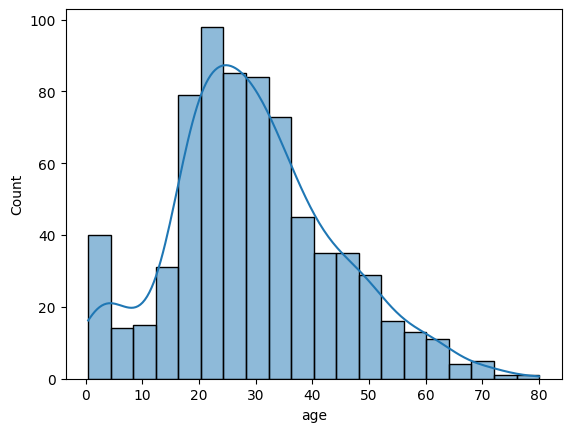

In [6]:
# Three methods to handle missing values 
# 1) mean value inputation 
# 2) Median value inputation 
# 3) Mode value Inputation 

# agar hum is dataset ka graph plot kare than
sns.histplot(df['age'] , kde=True)

In [10]:
# This above data somewhat looks liks a normal / gaussian distribution so in this type of distribution we can update the nan values with mean of
# that data 
df['age_mean'] = df['age'].fillna(df['age'].mean())

In [11]:
# Whenever their is different type of graph apart from normal distribution than we will replace the nan values with median value of that column 
df['age_mean'] = df['age'].fillna(df['age'].median())

In [18]:
# Whenever we have to deal with any categorial columns than at that time we can replace nan values with the mode value 
df['embarked_mode'] = df['embarked'].fillna('S')

In [ ]:
## Handling Inbalanced Dataset 
# 1) Up sampling 
# 2) Down sampling

# Lets say if we have an inbalanced dataset where a particular column has 900 yes and 100 no than we use the above two methods in first method
# we increase the datapoint of the minority (here its no) and in down scaling we decrease the datapoint (here its yes)

# 1) Up sampling 
df_minority = df[df['target'] = "No"]
df_majority = df[df['target'] = "Yes"]

import sklearn.utils import resample

df_minority_upsampled = resample(df_minority , replace = True, n_samples = len(df_majority) , random_state = 42)
# The Above code will create 900 point of no as well 


# 2) down sampling 
import sklearn.utils import resample

df_minority_upsampled = resample(df_majority , replace = False, n_samples = len(df_minority) , random_state = 42)
# The Above code will create 100 point of no as well

In [ ]:
# Handling Imbalanced Dataset Using SMOTE

# Just creating the dataset 
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

In [23]:
!pip install imblearn 


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from imblearn.oversampling import SMOTE 

oversample = SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

## Handling Imbalanced Dataset Using Python 

In [28]:
# How to get five number summary in numpy 
import numpy as np

age = [10,13,23,43,53,54,2,42,56,23,53,4,53,44,65,76,45 ,102]
# This is how we get it 
mini , q1 ,median , q3 , maxi = np.quantile(age , [0,0.25,0.50,0.75,1.0]) 
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
higher_fence = q3 + 1.5 * iqr

<Axes: >

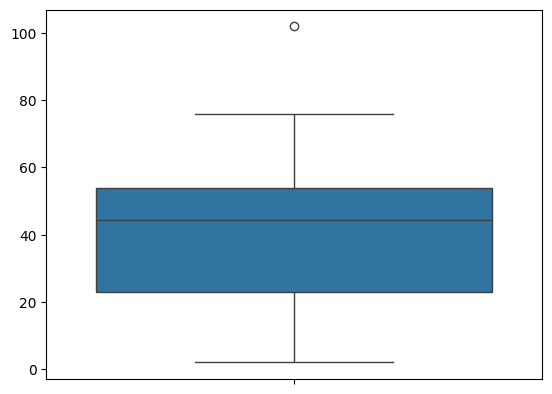

In [30]:
# How to create boxplot 
import seaborn as sns

sns.boxplot(age)

## Data Encoding 

In [ ]:
# There are three types of data encoding 
# 1) Nominal / OHE Encoding 
# 2) Label and Ordinal Encoding 
# 3) Target Guided Oridinal Encoding 

# 1) Nominal / OHE Encoding 
# This methods is used when their is a categorial column so lets say if we have a column of colors where their are list of 5 different colors than 
# what ohe does is  it will make five different columns named as red_color , blue_color etc and jab bhi red ayega than us column ko 1 de dega and 
# rest of column ko 0 rakh dega

# Disadvantages / When not to use it :-
# 1) Jab humare pas bohot zayada categories ho like agar ek column mai 15 categories hai than we should not use it because vo 10 new columns bana dega so
# 2) Agar humne itne zayada columns mai 0,1 dale than humara model is dataset pe hi zayada train ho jayega so vo real world mai itna efficient na ho 

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

## Create a simple dataframe 
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'green', 'red', 'blue']
})

# Creating an instance of onehotencoder 
encoder=OneHotEncoder()

# Firstly we will perform fit_transform vo 0 and 1 mai convert ho jayega 
encoded=encoder.fit_transform(df[['color']]).toarray()

# ek dataframe mai convert ho jayega jaha colors 0 , 1 mai convert ho gaye hai 
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

# Concating it into the dataset 
pd.concat([df,encoder_df],axis=1)



# 2) Label Encoding 
# This will also convert the categoral data into a numerical data But here each category is assigined a unique value lets say if we have 3 colours 
# [red,green,blue] than value might be assigined as red = 1 , green = 2 . blue = 3 

from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()
lbl_encoder.fit_transform(df[['color']])
# here if red is assigned 2 and green is assigned 1 than our model might think that red is greater than green but the reality might not be true 


# 3) Ordinal Encoding 
# Here also we will get unique value but it will be based on the rank like agar koi cheez upar hai usko kam value milegi and niche vale ko zayada 

from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large']
})
encoder=OrdinalEncoder(categories=[['small','medium','large']]) #Here list rank will be given to small than medium and than large 
encoder.fit_transform(df[['size']])

# If we want to check what rank is given to whom than 
encoder.transform([['small']])


# 4) Target Guided Oridinal Encoding 
# Here what we do is agar idar newyork two bar aa arah hai and dono bar kuch price hai so hum price ka mean ya median lenge and usko related kar denge 
# with new york 

df = pd.DataFrame({
    'city': ['New York', 'London', 'Paris', 'Tokyo', 'New York', 'Paris'],
    'price': [200, 150, 300, 250, 180, 320]
})

mean_price=df.groupby('city')['price'].mean().to_dict()

# So whereever their is neww york uska mean dikh jayega so we can refer new york with city_encoded 
df['city_encoded']=df['city'].map(mean_price)
df[['price','city_encoded']]



df["Classes"] = np.where(df["Classes"]=='not fire',0,1)